# Economic Inequality Team — End-to-End Data Investigation
## Adult Census Income Dataset

**This notebook walks you through the entire Data Investigation, start to finish:**

| Step | What you'll do |
|---|---|
| 1 | **Assess** — audit the raw dataset for quality problems |
| 2 | **Clean** — build and justify a documented cleaning pipeline |
| 3 | **Visualize** — build 4 publication-quality charts |
| 4 | **Story** — write a 150-word Data Brief |
| 5 | **HCD Design Sprint #2** — write your formal Data Problem Statement |
| 6 | **Baseline Models** — build 3 different machine learning models and compare them |
| 7 | **Fairness Check** — test whether your best model treats everyone equally |
| 8 | **Policy Recommendation** — turn your evidence into a specific, named ask |

**Dataset:** UCI Adult Census Income — 32,561 rows, 15 columns. Each row is one person from the 1994 US Census. The task economists and policymakers use this dataset for: understanding **what's associated with earning above vs. below $50K/year**, and where that story gets complicated by race, sex, and other demographics.

> ⚠️ **This dataset is real historical US Census data.** The patterns you'll find are not abstract — they describe real inequities that were true for real people in 1994, many of which persist today. Treat every finding as something a real person's life is reflected in.


## 📚 Vocabulary for This Notebook

| Term | Plain-English Meaning |
|---|---|
| **Sentinel value** | A fake value (like `?`) used to mean "missing" instead of leaving the cell truly blank — sneaky because code doesn't automatically recognize it as missing |
| **Sampling weight** | A number assigned to a row to make a *sample* statistically represent a *whole population* — not a fact about the individual person |
| **Binary target** | The thing you're trying to predict, when it only has two possible values (here: income `<=50K` or `>50K`) |
| **Feature** | A column used as an *input* to a model (age, education, hours worked...) |
| **Label** | The column the model is trying to *predict* (income category) |
| **Train/test split** | Splitting data so the model learns on one part and gets graded on a part it's never seen |
| **Baseline model** | The simplest reasonable model you build first — your benchmark for "is my fancier model actually better?" |
| **Class imbalance** | When one outcome (like `<=50K`) is much more common than the other — this can trick accuracy into looking better than it is |
| **Fairness check** | Testing whether a model's accuracy holds up equally across different demographic groups, not just on average |


## Setup — Load the Dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

# Load the Adult dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(url,header=None, names=columns)

# Remove leading/trailing spaces from string values
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# printing the rows and columns of the dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Verify column names
print(df.columns.tolist())

df.head()


Shape: 32561 rows × 15 columns
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step 1 — Assess

Run the three commands below. For each: *what is this telling you, and what might it be hiding?*


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


### 🕵️ The trap: `isnull()` just said zero missing values. Is that true?

Open one of the categorical columns below and look closely at the values.


In [ ]:
df['workclass'].value_counts()


,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


Notice anything? This dataset doesn't use a true blank for missing data — it uses the **sentinel value `'?'`**. `pandas` has no way of knowing that's supposed to mean "missing" unless you tell it. This is exactly the kind of missingness that `isnull()` misses — literally.

Run this to find every column where `'?'` is hiding as a disguised missing value:


In [ ]:
for col in df.select_dtypes(include='object').columns:
    count = (df[col].astype(str).str.strip() == '?').sum()
    if count > 0:
        print(f'{col}: {count} disguised missing values ({count/len(df)*100:.1f}%)')


workclass: 1836 disguised missing values (5.6%)
occupation: 1843 disguised missing values (5.7%)
native-country: 583 disguised missing values (1.8%)


### 📝 Data Audit Report

> **Issue 1 — Disguised missing values:** the columns workclass, occupation, and native-country use `'?'` to mean missing, totaling 4262 cells.
>
> **Issue 2 — Duplicate rows:** I found 24 duplicate rows using `df.duplicated().sum()`.
>
> **Issue 3 — A column that isn't really about the person:** `fnlwgt` is a sampling weight (look it up in the vocabulary table above), not a personal attribute — It should not be used as a feature in a model that predicts something about an individual because it represents how many people a record represents in the population rather than a characteristic of that specific person.
>
> **Issue 4 — Possible outliers:** the `capital-gain` and `capital-loss` columns are heavily skewed — most values are 0, but a few are very large. Run `df['capital-gain'].describe()` and note the gap between the 75th percentile and the max.
>
> **Issue 5 — Class imbalance:** run `df['income'].value_counts(normalize=True)` below. What percentage of people in this dataset earn `>50K`? Why does that number matter for anything you build later in this notebook?

About 24.1% of people in this dataset earn >50K, while about 75.9% earn <=50K. This matters because a model could achieve high accuracy by mostly predicting the majority class (<=50K) without actually learning meaningful patterns, so metrics like precision, recall, and F1 score are important for evaluating performance.

In [ ]:
df['capital-gain'].describe()


,capital-gain
count,32561.000000
mean,1077.648844
std,7385.292085
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


In [ ]:
df['income'].value_counts(normalize=True)


,proportion
income,
<=50K,0.75919
>50K,0.24081


## Step 2 — Clean

Every step below needs a one-sentence justification. **Fill in every `___` — this pipeline will not run until you do.**


In [ ]:
df_clean = df.copy()

# --- 2a: Strip whitespace ---
# Justification: this dataset has leading spaces on every text value (a common export artifact) —
# ' Male' and 'Male' look the same to a human but are different strings to Python
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()


# --- 2b: Replace the '?' sentinel with real missing values ---
# Justification: The '?' character represents missing data, but pandas does not automatically recognize it as such. Replacing it with `np.nan` allows pandas' missing value handling functions to work correctly.
df_clean = df_clean.replace('?', np.nan)


# --- 2c: Handle the missing values ---
# Justification: Missing values in `workclass`, `occupation`, and `native-country` are being removed. This is an analytical choice, assuming that these rows are not informative without this data, or that filling them would introduce bias.
# Think carefully here — is 'workclass' missing at random, or could it be missing because
# someone is unemployed / never worked / retired? Dropping vs. filling is an analytical choice,
# not just a technical one.
df_clean = df_clean.dropna(subset=['workclass', 'occupation', 'native-country'])
# or, alternative: df_clean['workclass'] = df_clean['workclass'].fillna('Unknown')


# --- 2d: Drop the sampling weight column ---
# Justification: fnlwgt describes how many people in the population this row represents,
# not a fact about this individual — it should not be used to predict anything about a person
df_clean = df_clean.drop(columns=['fnlwgt'])


# --- 2e: Duplicate rows ---
# Justification: Duplicate rows can skew analysis and model training by overrepresenting certain observations. Removing them ensures each observation is unique.
df_clean = df_clean.drop_duplicates().reset_index(drop=True)


# --- 2f: Create a binary numeric target ---
# Justification: models need numbers, not text categories, to predict
df_clean['income_binary'] = (df_clean['income'].str.strip() == '>50K').astype(int)

print('Cleaned shape:', df_clean.shape)
df_clean.head()

Cleaned shape: (26904, 15)


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


### ✅ Verify


In [ ]:
assert df_clean.isnull().sum().sum() == 0, "There are still missing values somewhere"
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert 'fnlwgt' not in df_clean.columns, "fnlwgt should have been dropped"
assert df_clean['income_binary'].isin([0, 1]).all(), "income_binary should only contain 0 or 1"

print("All checks passed. The dataset is clean.")
print('Rows kept:', len(df_clean), f'({len(df_clean)/len(df)*100:.1f}% of original)')


All checks passed. The dataset is clean.
Rows kept: 26904 (82.6% of original)


### 📝 Data Limitations

Even after cleaning, this dataset still cannot tell us **the reasons why individuals earn certain incomes or the personal circumstances that influence their careers,** because **the dataset only includes recorded demographic, education, occupation, and employment information and does not capture factors such as motivation, career choices, access to opportunities, or economic conditions.** This is 1994 U.S. Census data, **so it cannot capture changes in the economy and workforce since then, including the growth of technology, remote work, new industries, changes in education requirements, and shifts in employment opportunities.**


## Step 3 — Visualize / Exploratory Data Analysis

Four chart types. Every chart needs: **labeled axes with units**, a **finding-based title**, and **2 sentences of interpretation**.


### Chart 1 — Histogram: Distribution of Weekly Working Hours Across Income Groups



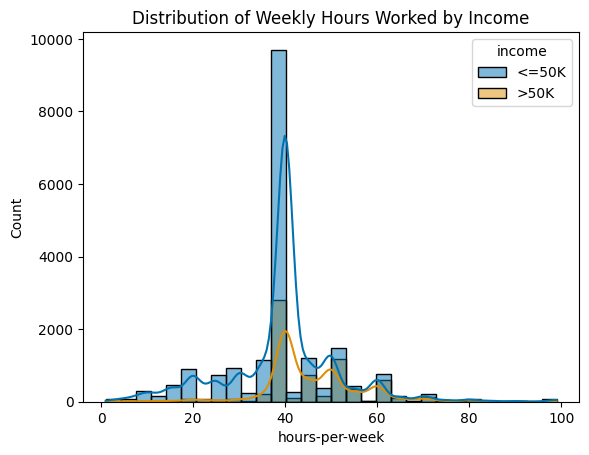

In [ ]:
sns.histplot(
    data=df_clean,
    x='hours-per-week',
    hue='income',
    bins=30,
    kde=True
)
plt.title("Distribution of Weekly Hours Worked by Income")
plt.show()


> **Interpretation:**
The histogram shows that individuals earning more than 50K generally work more hours per week compared to individuals earning 50K or less. The average weekly hours worked for the >50K group is about 45.9 hours, while the <=50K group averages about 39.5 hours. However, there is still overlap between the two groups, showing that hours worked alone does not completely determine income.

### Chart 2 — Box Plot: Comparison of Weekly Work Hours Between Income Categories



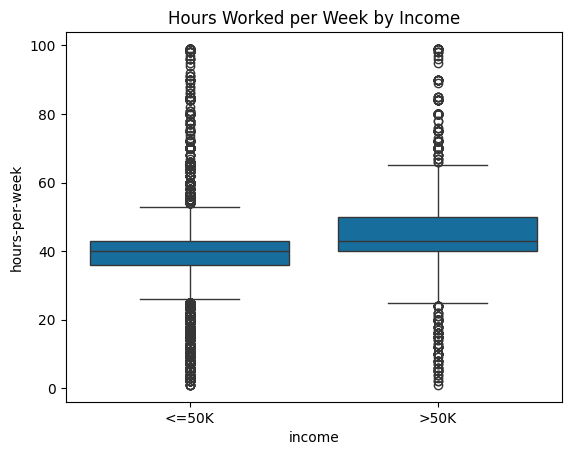

In [ ]:
sns.boxplot(
    data=df_clean,
    x='income',
    y='hours-per-week'
)
plt.title("Hours Worked per Week by Income")
plt.show()


> **Interpretation:**
The box plot shows that the typical weekly hours worked are higher for individuals earning more than 50K. The median hours worked are 43 hours for the >50K group compared to 40 hours for the <=50K group. Both groups contain individuals who work as many as 99 hours per week, showing that some people have unusually long work schedules.

### Chart 3 — Bar Graph: How Occupation Influences Weekly Work Hours Across Income Groups



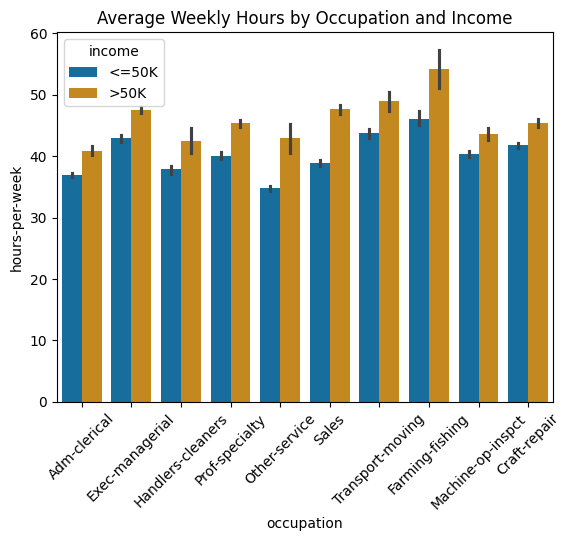

In [ ]:
top_occ = df_clean['occupation'].value_counts().head(10).index
subset = df_clean[df_clean['occupation'].isin(top_occ)]

sns.barplot(
    data=subset,
    x='occupation',
    y='hours-per-week',
    hue='income'
)
plt.xticks(rotation=45)
plt.title("Average Weekly Hours by Occupation and Income")
plt.show()

> **Interpretation:**
This graph compares average weekly hours worked across the 10 most common occupations for individuals in different income groups. Across most occupations, individuals earning more than 50K tend to have slightly higher average weekly hours compared to those earning 50K or less. However, the differences are relatively small, suggesting that occupation and hours worked may contribute to income differences, but they are not the only factors that determine income.

### Chart 4 — Stacked Bar Graph: How Education Level Influences Income Distribution Across Groups



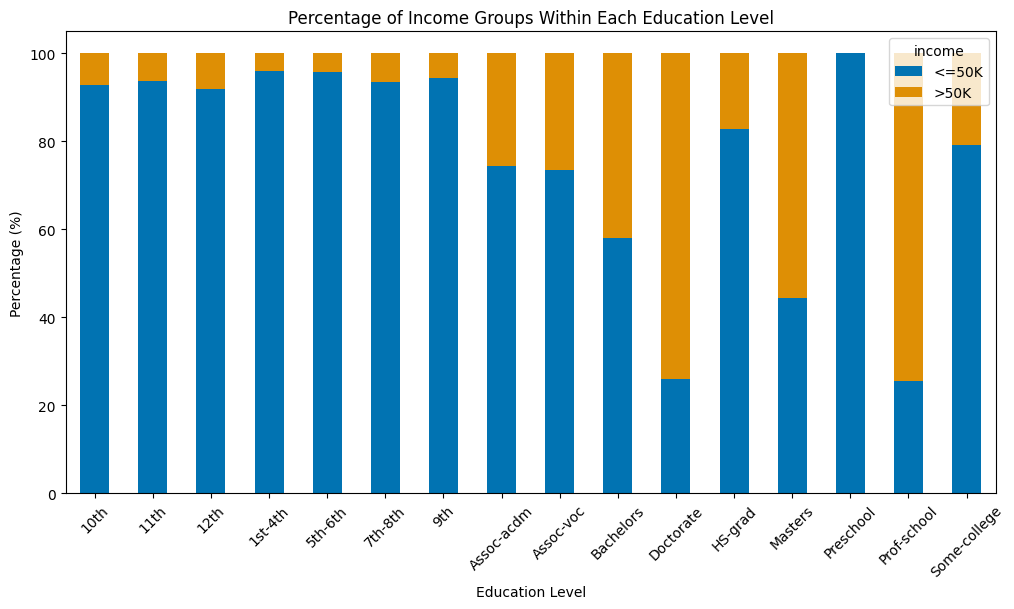

In [ ]:
education_income = pd.crosstab(
    df_clean['education'],
    df_clean['income'],
    normalize='index'
) * 100

education_income.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Percentage of Income Groups Within Each Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

> **Interpretation:**

The education analysis shows a strong relationship between education level and income. Individuals with advanced degrees had a higher percentage of people earning more than 50K; for example, 73.9% of individuals with doctorates and 55.5% of individuals with master’s degrees earned above 50K. In comparison, lower education levels had much smaller percentages of individuals in the higher income group.

### Chart 5 — Scatter Plot: Relationship Between Age, Work Hours, and Income Level


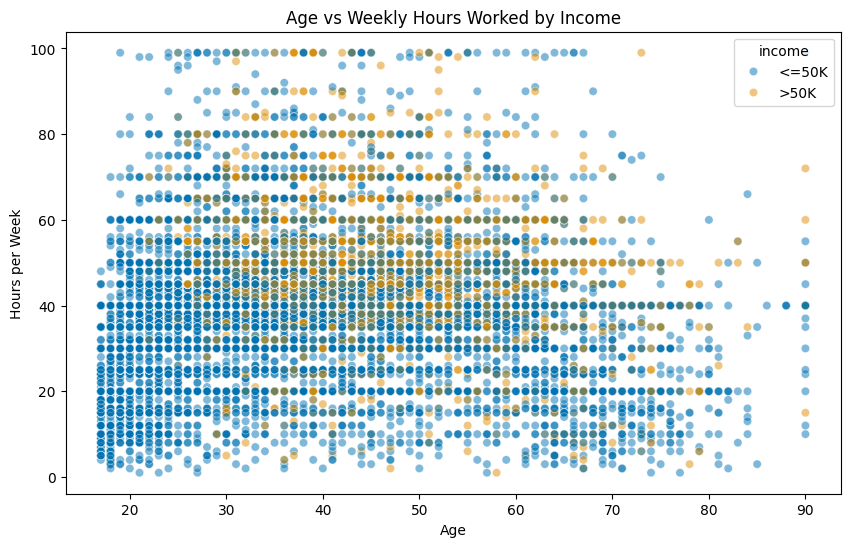

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='age',
    y='hours-per-week',
    hue='income',
    alpha=0.5
)

plt.title("Age vs Weekly Hours Worked by Income")
plt.xlabel("Age")
plt.ylabel("Hours per Week")

plt.show()

> **Interpretation:**

The analysis shows that individuals earning more than 50K are older on average compared to those earning 50K or less. The average age of the >50K group is about 44.1 years, while the <=50K group averages about 37.3 years. This suggests that age may be related to income, possibly because older individuals may have more work experience or career advancement opportunities.

## Step 4 — Story

### 📝 Data Brief (150 words)

Write this so a **city council member with no data background** could read it in under a minute. No jargon, no code, no chart references. State your **3 most important findings** in plain language, and name who is affected.

> ___


This investigation examines factors associated with whether individuals earn above or below 50,000 per year using the Adult Census Income dataset. The analysis found that higher-income individuals generally worked more hours per week, averaging about 45.9 hours compared to 39.5 hours for lower-income individuals. Education level was also strongly related to income, with individuals holding advanced degrees having higher rates of earning above 50,000. Age showed a similar pattern, as individuals earning above 50,000 were older on average than those earning less. These findings suggest that income differences are influenced by multiple factors, including education, work experience, and employment patterns. Understanding these patterns can help researchers and policymakers identify groups that may face economic disadvantages and better evaluate factors connected to income inequality.

In [ ]:
# Average hours worked by income
df_clean.groupby('income')['hours-per-week'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
income,,,,
<=50K,39.530314,40.0,12.343806,20024
>50K,45.920930,43.0,11.058140,6880


In [ ]:
# Average hours by occupation and income
df_clean.groupby(['occupation', 'income'])['hours-per-week'].mean().sort_values()

,,hours-per-week
occupation,income,
Priv-house-serv,<=50K,32.678571
Other-service,<=50K,34.741193
Priv-house-serv,>50K,35.000000
Adm-clerical,<=50K,36.960582
Handlers-cleaners,<=50K,37.866790
Tech-support,<=50K,38.528620
Sales,<=50K,38.893305
Armed-Forces,>50K,40.000000
Prof-specialty,<=50K,40.091127


## 🎯 HCD Design Sprint #2 — Define: Data Problem Statement

> **Our investigation asks:** How do factors such as education level, age, occupation, and work hours relate to whether individuals earn above or below 50,000 per year?
>
> **The dataset we are using is:** UCI Adult Census Income dataset, US Census Bureau, 1994, one row per adult respondent.
>
> **The key variable we are analyzing is:** `income` — whether a person earns above or below $50,000/year, recoded as `income_binary` (0 = ≤50K, 1 = >50K).
>
> **Our investigation matters because:** Our investigation matters because understanding income patterns can help identify barriers to economic opportunity. Without better understanding of these patterns, lower-income workers and groups with fewer educational or employment opportunities may continue to face economic inequality.
>
> **We define a meaningful finding as:** We define a meaningful finding as a consistent difference in income outcomes between groups, such as a large gap in the percentage of individuals earning above 50,000 based on education level, occupation, or demographic factors.

**Team checklist before submitting:**
- [✔ ] Our question can actually be answered with the columns in this dataset — we checked
- [✔ ] We named a real population affected by this issue
- [✔ ] We defined what a "meaningful finding" looks like *before* building any model


## Step 6 — Baseline Models

**What is a "baseline model"?** The simplest reasonable model you can build. Not your best model — your *starting point*. Every improvement you make later gets measured against it.

**Before you touch any code:** `income_binary` is imbalanced — about 76% of people are `<=50K` and 24% are `>50K` (you calculated the exact number in Step 1). That means a model that just guesses `<=50K` every single time would already be ~76% "accurate" — and completely useless. Keep this in mind for every accuracy number you see below.


### Prepare the features

Models need numbers, not text categories. `pd.get_dummies()` turns each category (like `workclass`) into its own 0/1 column.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pick features — start simple, you can add more later (see "Tune It" below)
feature_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex']

X = df_clean[feature_cols].copy()
X = pd.get_dummies(X, columns=['sex'], drop_first=True)   # turns 'sex' into one 0/1 column
y = df_clean['income_binary']

print('Feature columns:', list(X.columns))
X.head()


Feature columns: ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex_Male']


,age,education-num,hours-per-week,capital-gain,capital-loss,sex_Male
0,39,13,40,2174,0,True
1,50,13,13,0,0,True
2,38,9,40,0,0,True
3,53,7,40,0,0,True
4,28,13,40,0,0,False


In [ ]:
# Train/test split — the model learns on 80%, gets graded on the 20% it's never seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Training set income>50K rate:', y_train.mean().round(3))
print('Test set income>50K rate:', y_test.mean().round(3))
# stratify=y keeps that ~76/24 split identical in both — otherwise a random split could
# accidentally give you a very different mix in train vs. test


Training rows: 21523
Test rows: 5381
Training set income>50K rate: 0.256
Test set income>50K rate: 0.256


In [ ]:
# Scale the numeric features — required for k-NN (distance-based), harmless for the others
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

In [ ]:
# import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# define models
models = {

    "Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression":
        LogisticRegression(max_iter=1000, class_weight='balanced'),
    "K-Nearest Neighbors":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Support Vector Machine":
        SVC(),

    "Neural Network (MLP)":
        MLPClassifier(max_iter=500, random_state=42)
}

In [ ]:
results = []

# Define the preprocessor outside the loop
# It applies StandardScaler to numeric features and OneHotEncoder to categorical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

for name, model in models.items():

    if name == "Naive Bayes":
        # For Naive Bayes, we transform the data once outside the pipeline
        # because GaussianNB does not accept sparse matrices directly and
        # the pipeline fit_transform would output a sparse matrix if one-hot encoding is applied.
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()
            X_test_processed = X_test_processed.toarray()

        model.fit(X_train_processed, y_train)

        predictions = model.predict(X_test_processed)

    else:

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions, zero_division=0),

        "Recall": recall_score(y_test, predictions, zero_division=0),

        "F1 Score": f1_score(y_test, predictions, zero_division=0)

    })

In [ ]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

results_df.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.8366,0.7983,0.4833,0.6021
1,Logistic Regression,0.7519,0.5106,0.7151,0.5958
2,Neural Network (MLP),0.8272,0.7693,0.4629,0.5780
3,AdaBoost,0.8199,0.7294,0.4702,0.5718
4,Random Forest,0.8077,0.6731,0.4818,0.5616
5,Decision Tree,0.8021,0.6592,0.4680,0.5474
6,Extra Trees,0.8030,0.6656,0.4615,0.5451
7,K-Nearest Neighbors,0.7932,0.6268,0.4724,0.5387
8,Support Vector Machine,0.8188,0.8052,0.3844,0.5204
9,Naive Bayes,0.7850,0.6540,0.3379,0.4456


In [ ]:
# Train the best model for fairness check

best_model = GradientBoostingClassifier(random_state=42)

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

best_pred = best_pipeline.predict(X_test)

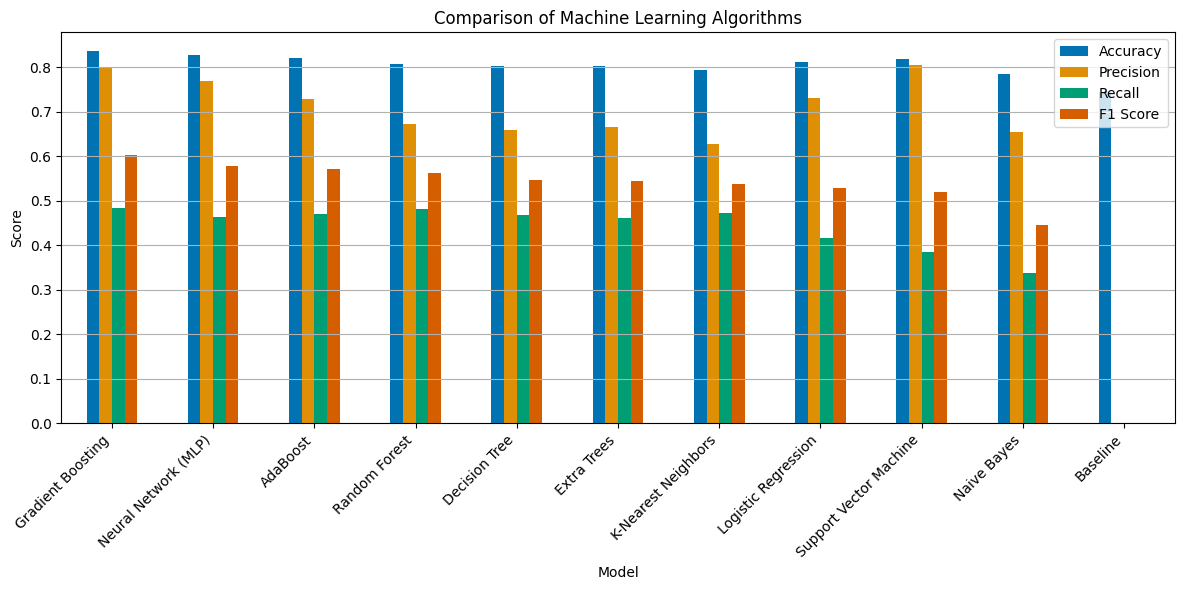

In [ ]:
# bar plot
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Algorithms")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 📝 Written comparison

> **Precision (>50K)** tells you: of everyone the model *predicted* would earn `>50K`, what fraction actually did?
>
> **Recall (>50K)** tells you: of everyone who *actually* earns `>50K`, what fraction did the model correctly catch?
>
> Which model has the highest accuracy? **Gradient Boosting (83.66%)**. Which model has the best recall on `>50K`? **Gradient Boosting (48.33%)**.

If this model were used to flag people for a loan-eligibility review, would you rather have higher precision or higher recall — and why does the cost of a false negative vs. a false positive matter here?

For a loan-eligibility review, I would prefer higher recall because it reduces false negatives. A false negative would mean incorrectly identifying someone as unlikely to qualify when they may actually qualify, which could unfairly prevent someone from receiving an opportunity. However, higher recall can also increase false positives, meaning some people may be reviewed even if they do not qualify.


## 🔧 Tune It — Now Make It Better

Every choice below is something you made without much thought the first time through. Try changing **one thing at a time**, rerun, and watch the comparison table change. Three tiers of hint if you get stuck — try the top one first.

**1. Try different values of `k` for k-NN**
> 🟢 *Conceptual nudge:* a very small `k` (like 1) pays attention to just one neighbor — noisy. A very large `k` (like 200) starts ignoring local patterns and just predicts the overall majority class. Where's the sweet spot?
> 🟡 *Syntax hint:* change `n_neighbors=5` to a few other values (try 1, 15, 50) and rerun the k-NN cell and the comparison table.
> 🔵 *Bridge:* once you find a `k` that improves recall, ask — did accuracy go up too, or did they move in opposite directions? That tradeoff is the whole story of Week 4.

**2. Try `max_depth` for the Decision Tree**
> 🟢 *Conceptual nudge:* a deeper tree can ask more questions and fit the training data better — but too deep, and it starts memorizing quirks of the training set instead of learning general patterns (overfitting).
> 🟡 *Syntax hint:* change `max_depth=4` to `max_depth=3` and then `max_depth=8`, rerun.
> 🔵 *Bridge:* does a deeper tree do better on the test set, or just the training set? (Add `tree.score(X_train, y_train)` to compare.)

**3. Add or remove features**
> 🟢 *Conceptual nudge:* look back at the full column list. Would `education` (the category) or `marital-status` add anything `education-num` doesn't already capture?
> 🟡 *Syntax hint:* add a column name to `feature_cols`, rerun `pd.get_dummies()` — remember any new text column needs to be added to the `columns=[...]` list too.
> 🔵 *Bridge:* did the new feature actually change accuracy, or just make the model more complicated? More features isn't automatically better.

**4. Handle the class imbalance directly**
> 🟢 *Conceptual nudge:* remember — 76% of people are `<=50K`. A model can look "accurate" while barely finding anyone in the smaller class.
> 🟡 *Syntax hint:* add `class_weight='balanced'` inside `LogisticRegression(...)` and rerun.
> 🔵 *Bridge:* what happened to precision vs. recall on `>50K`? Which one improved, and which one got worse — and is that trade worth it for your team's investigation?

Adding class weights improved recall for the >50K group, increasing it from 41.57% to 71.51%. However, precision decreased from 73.05% to 51.06%, meaning the model identified more true higher-income individuals but also created more false positives. For this investigation, the tradeoff may be worthwhile because missing individuals who actually earn above 50K is more harmful than reviewing some incorrect predictions.




## Step 7 — Fairness Check

Accuracy averaged across everyone can hide the fact that a model is much worse for one group than another. Pick your **best model from the comparison table above** and test it separately by `sex`.


In [ ]:
# Pick whichever model performed best above — this example uses logistic regression
best_pred = best_pred
X_test_with_group = X_test.copy()
X_test_with_group['actual'] = y_test.values
X_test_with_group['predicted'] = best_pred

for group_value in X_test_with_group['sex_Male'].unique():
    group_label = 'Male' if group_value == 1 else 'Female'
    mask = X_test_with_group['sex_Male'] == group_value
    group_acc = accuracy_score(X_test_with_group.loc[mask, 'actual'], X_test_with_group.loc[mask, 'predicted'])
    group_recall = recall_score(X_test_with_group.loc[mask, 'actual'], X_test_with_group.loc[mask, 'predicted'])
    print(f'{group_label}: accuracy={group_acc:.3f}, recall(>50K)={group_recall:.3f}, n={mask.sum()}')


Male: accuracy=0.803, recall(>50K)=0.490, n=3587
Female: accuracy=0.904, recall(>50K)=0.450, n=1794


### 📝 Fairness Interpretation

> Is accuracy roughly equal across groups? Is recall roughly equal? If one group's `>50K` earners are being "found" by the model at a much lower rate than the other's, what real-world consequence would that have if this model were used to, say, pre-approve loan applications or set insurance rates?

Accuracy is not completely equal across groups, as the model performs better for the female group (90.4%) compared to the male group (80.3%). Recall is relatively similar between groups, with males at 49.0% and females at 45.0%, meaning the model identifies actual >50K earners at a slightly higher rate among males. If one group’s higher-income earners were detected at a much lower rate, the model could create unfair outcomes by limiting access to opportunities, such as loan approvals or financial services. This demonstrates why evaluating models across demographic groups is important instead of relying only on overall accuracy.
>
> **Remember:** this model was trained on 1994 data reflecting the economy and workforce of that era. A "fair" model on this historical data is not the same as a model that would be fair if applied to people today.


## Step 8 — Policy Recommendation

**Based on our data analysis, we recommend** **that the U.S. Department of Labor take the following action:** expand workforce development and education support programs for individuals with fewer educational opportunities, because our evidence shows education level is strongly associated with income outcomes, with 73.9% of individuals with doctorates and 55.5% of individuals with master’s degrees earning above $50K, compared to much lower percentages for lower education levels. **This implies that limited access to education and job training can contribute to lower earning potential and reduced economic mobility for individuals with lower levels of education and lower incomes if unaddressed.**

**One thing we would want anyone citing this finding to know first:** This dataset is based on the 1994 U.S. Census, so the results may not fully reflect today's economy, workforce, or employment opportunities.


## 📓 Data Journal — Exit Ticket

1. **What dataset or technique did I work with today?**

I worked with the UCI Adult Census Income dataset and used data cleaning, exploratory data analysis, data visualization, and machine learning techniques to predict whether an individual earns more than 50K per year.

2. **What pattern or anomaly surprised me?**

I was surprised by how strongly education level was associated with income. Individuals with advanced degrees were much more likely to earn above 50K, while most people with lower education levels earned 50K or less.

3. **Who is represented in this data — and who is invisible?** (Think about who was even included in a 1994 US Census survey, and who wasn't.)

This dataset represents adults included in the 1994 U.S. Census. It does not represent people outside the United States, individuals who were not included in the census, or changes in today's workforce, economy, and technology.

4. **Looking at your fairness check: what would an ethical data scientist refuse to claim about this model, even if the average accuracy looked good?**

An ethical data scientist would not claim that the model is completely fair or suitable for making important decisions based only on its overall accuracy. The model showed different performance across demographic groups and was trained on historical data, so its predictions should be interpreted with caution.


## Conclusion

1. Project Title: Predicting Income Levels Using Census Data

This project analyzes factors associated with whether individuals earn above or below $50K per year. It uses demographic, education, and employment information from the UCI Adult Census Income dataset to explore patterns in income outcomes.

2. One Sentence Summary: We analyzed Census data to understand how factors such as education, age, occupation, and work hours relate to income levels. We also built machine learning models to predict whether an individual earns above or below $50K.

3. The Problem: Income inequality affects individuals’ access to financial security, career opportunities, and quality of life. Understanding which factors are associated with higher income can help identify patterns in economic opportunity and areas where support may be needed.

4. The Data: This project used the UCI Adult Census Income dataset from the 1994 U.S. Census, which contains information about adults including age, education, occupation, hours worked per week, and income. After cleaning the dataset by handling missing values, removing duplicates, and removing unnecessary variables, 26,904 records remained. Exploratory analysis showed that education level and work hours were strongly related to income differences.

5. What We Did: We cleaned and prepared the dataset by removing missing values, correcting formatting issues, dropping the sampling weight variable, and converting income into a binary target for machine learning. We performed exploratory data analysis through visualizations and tested multiple machine learning models, including Gradient Boosting, Logistic Regression, Random Forest, Decision Tree, and Neural Network models. These models were evaluated using accuracy, precision, recall, and F1 score to compare their performance.

6. What We Found: The Gradient Boosting model achieved the highest accuracy with 83.66% and the highest F1 score among the tested models. The analysis showed that individuals with higher education levels were more likely to earn above $50K, although income cannot be explained by one factor alone.

7. Fairness Check: The model was evaluated across male and female groups to determine whether performance differed between groups. Male accuracy was 80.3% and female accuracy was 90.4%, showing that model performance was not identical across groups and should be carefully considered before real-world use.

8. Limits And What's Next: This dataset is based on the 1994 U.S. Census, meaning it does not capture modern changes such as remote work, technology-driven careers, and changes in the economy. Future improvements could include using newer data, adding more relevant variables, and testing additional methods to improve fairness.

9. How To Run It: This project can be run using the Google Colab notebook, which contains the full process from data cleaning to machine learning evaluation. The notebook requires the dataset and Python libraries included in the notebook setup, and the full analysis can be completed within a few minutes.

10. Team and Roles: This project was completed by Misheeta, Sarakshi, Nisha, and Simran. Each team member contributed to different parts of the data investigation process, including data cleaning, exploratory analysis, visualization, machine learning, and documentation.